In [75]:
import numpy as np
import matplotlib.pyplot as plt

In [76]:
def evaluate_spline(x_data, y_data, M, x_query):
  n = len(x_data)
  h = np.diff(x_data)
  i = np.searchsorted(x_data, x_query, side='right') - 1
  i = np.clip(i, 0, n - 2)
  hi = h[i]
  dx_left = x_query - x_data[i]
  dx_right = x_data[i+1] - x_query
  S = (
    (M[i] / (6*hi)) * dx_right**3 +
    (M[i+1] / (6*hi)) * dx_left**3 +
    (y_data[i] /hi - M[i] *hi/6) * dx_right +
    (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left
  )
  return S

In [77]:
def cubic_spline(x, y):
  n = len(x)
  h = np.diff(x)

  A = np.zeros(n - 2)
  B = np.zeros(n - 2)
  C = np.zeros(n - 2)
  D = np.zeros(n - 2)

  for i in range(0, n - 2):
    A[i] = h[i]
    B[i] = 2 * (h[i] + h[i+1])
    C[i] = h[i+1]
    D[i] = 6 * ((y[i+2] - y[i+1]) / h[i+1] - (y[i+1] - y[i]) / h[i])

  for i in range(1, n-2):
    w = A[i] / B[i-1]
    B[i] = B[i] - w * C[i-1]
    D[i] = D[i] - w * D[i-1]

  z_in = np.zeros(n-2)
  z_in[-1] = D[-1] / B[-1]
  for i in range(n-4, -1, -1):
    z_in[i] = (D[i] - C[i] * z_in[i+1]) / B[i]

  z = np.zeros(n)
  z[1:-1] = z_in
  return z

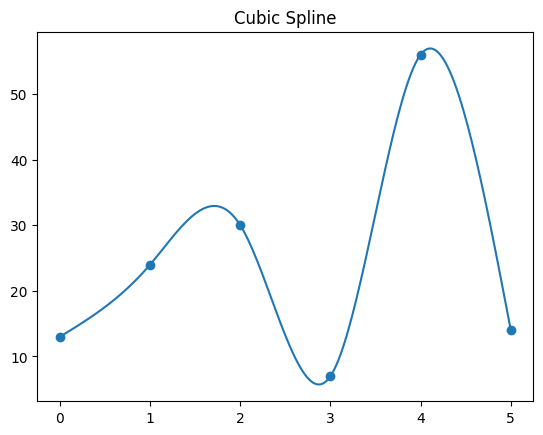

In [78]:
x = np.array([0,1,2,3,4,5])
y = np.array([13,24,30,7,56,14])

z = cubic_spline(x, y)

x_vals = np.linspace(0,5,200)
y_vals = [evaluate_spline(x, y, z, xv) for xv in x_vals]

plt.plot(x_vals, y_vals)
plt.scatter(x, y)
plt.title("Cubic Spline")
plt.show()